In [27]:
import sys
from os import path, getcwd
import pathlib
from sklearn.metrics import average_precision_score, roc_auc_score

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

# data paths
DATA_DIR = path.join(ROOT, 'data/')
# checkpoints of preprocessed data
CHECKPOINTS = {'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.15_14-22-33_normal/'),
               'nf_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.24_13-35-41_new_loss_old/'),
               'NICE': path.join(DATA_DIR, 'checkpoints/nf/NICE_blocks-6_mnist_cls-0/08.17_07-29-03_NICE/'),
               #'conv_net': path.join(DATA_DIR, 'checkpoints/conv/conv_net_mnist_cls-0/08.16_09-58-53/'),
               'continued_new_loss': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.12_08-57-06_new_loss_continued/'),
               #'nf_new_reg_50/50': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.10_12-06-20_new_reg_50/'),
               #'nf_new_reg_90/10': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.10_12-44-46_new_reg_0.1/'),
               #'nf_new_loss_exp_2': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-15-57_exp_2/'),
               #'nf_new_loss_exp_4': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-16-28_exp_4/'),
               #'nf_new_loss_exp_1.2': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-30-22_exp_1.2/'),
               #'nf_new_loss_exp_1.5': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.13_09-33-39_exp_1.5/'),
               #'nf_no_bias': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.11_08-25-27_no_bias/'),
               #'nf_indep': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.29_20-56-46_indep/'),
               #'survae': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_14-20-54_normal/'),
               #'survae_new_loss': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.10_20-27-32_new_loss/'),
               #'survae_no_bias': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/06.11_08-26-49_no_bias/'),
               #'survae_hierarchy': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-4_scales-5_pool-max_mnist_cls-0/06.11_09-35-05_hierarchy/'),
               #'iwae_no_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.09_08-18-56_no_bias/'),
               #'iwae_with_bias': path.join(DATA_DIR, 'checkpoints/iwae/k-16_latent-30_mnist_cls-0/06.10_20-27-53_with_bias/')
               }

print(f'Loading preprocessed data from:\n {CHECKPOINTS}')


%reload_ext autoreload
%autoreload 2

# Plotting Functions
from plotting import *

from misc.common_functions import *
from precomputation.initialization import load_data, load_preprocessings
from precomputation.pre_sampling import SampleType

_=%matplotlib inline

# config
configs, MAIN_TEST_CLS = load_configs(CHECKPOINTS, DATA_DIR)
for _, args in configs.items():
    args.new_use_case = False

# Data
all_loaders = load_data(configs)

# Precomputed information
all_models, samples, artificial_images, additionals = load_preprocessings(CHECKPOINTS)

from IPython.display import clear_output
from torch.distributions.multivariate_normal import MultivariateNormal
from scipy.stats import kstest, norm
from warnings import warn

def additional_stuff():
    priors = dict()
    for model, value in additionals.items():
        latent_dim_size = value['total_latent_dim']
        data_shape = value['data_shape']

        data_shape_size = np.prod(data_shape)
        #warn('used datashape')
        #gauss_size = data_shape_size
        gauss_size = latent_dim_size
        priors[model] = MultivariateNormal(torch.zeros(gauss_size), torch.eye(gauss_size))
        #  / (np.log(2)*gauss_size)
        gauss_samples_count = 5000
        gauss = torch.normal(0, 1, size=(gauss_samples_count, gauss_size))
        latent_info = (np.arange(gauss_samples_count)*-1, priors[model].log_prob(gauss).detach().numpy(),
                       gauss.detach().numpy(), np.zeros(gauss_samples_count))
        all_models[model][STD_NORMAL_CLASS] = latent_info

    interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, STD_NORMAL_CLASS, 1, 7, 8, 3]
    all_models = filter_interesting_losses(all_models, interesting_classes)

#no_iwae_losses = {'nf': all_models['nf'], 'survae': all_models['survae']}
#iwae_losses = {'iwae': all_models['iwae']}

def to_bpd(llh, model):
    return llh / (np.log(2) * np.prod(configs[model].data_shape))

def show_histograms(all_models, show_hist=False, hide_output=True):
    """This prints the histogram of losses"""
    #plt.figure(figsize=(20, 10))

    for cls, losses, mean in all_models:
        # Make training class thick
        kde_kws = dict()
        if cls==configs['nf'].training_class or cls==MAIN_TRAIN_CLS or cls==STD_NORMAL_CLASS:
            kde_kws['linewidth'] = 3
        
        color=get_class_color(cls)
        
        sns.distplot(losses, label=get_legend_label(cls, mean), hist=show_hist, kde_kws=kde_kws, color=color, 
                     hist_kws={"histtype": "step", "linewidth": 3, "alpha": 0.1}, norm_hist=True)
    
    plt.ylabel('Density', fontsize=AXIS_FONT_SIZE)
    
    plt.legend(fontsize=LEGEND_FONT_SIZE)
    if hide_output:
        clear_output()
        
print('---done---')

Loading preprocessed data from:
 {'nf': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.15_14-22-33_normal/', 'nf_new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/06.24_13-35-41_new_loss_old/', 'NICE': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/NICE_blocks-6_mnist_cls-0/08.17_07-29-03_NICE/', 'continued_new_loss': 'C:\\Mega\\trunk\\master-thesis\\data/checkpoints/nf/RealNVP_blocks-6_mnist_cls-0/08.12_08-57-06_new_loss_continued/'}
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: normal
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: NICE
debug: False
-------------------------------------------------------------
Normalizing Flow
wandb_name_ext: new_loss_continued
debug: False
Da

In [28]:
for models, config in configs.items():
    #if 'new_loss' in dir(config) and config.new_loss is True:
    if 'avg_log_volume' in additionals[models]:
        print(f'Avg log volume: {model_short_to_name(models)} {additionals[models]["avg_log_volume"]}')

Avg log volume: Normalizing Flow None
Avg log volume: Normalizing Flow - new loss 339.3549499511719
Avg log volume: NICE None
Avg log volume: pretrained NF, continued with new loss None


This studentizes the data

##  Quick Sanity Check if all images aligne

In [3]:
for m_1 in all_models:
    for m_2 in all_models:
        # (I know, I compute twice as much as needed)
        if m_1 == m_2:
            continue
        for cls in all_models[m_1]:
            imgs_1 = all_models[m_1][cls][IMG_IDX]
            imgs_2 = all_models[m_2][cls][IMG_IDX]
            a = all_models[m_1][cls][IMG_IDX] - all_models[m_2][cls][IMG_IDX]
            np.testing.assert_array_equal(all_models[m_1][cls][IMG_IDX], all_models[m_2][cls][IMG_IDX], f'{m_1} or in {m_2}')

In [29]:
def use_volume_changing_lln():
    for model in all_models:
        if 'new_loss' not in model:
            continue
        bpd_factor = (np.log(2) * 28*28)
        
        losses = all_models[model]
        main_cls = losses[MAIN_TRAIN_CLS]
        lln = main_cls[LLN_IDX] * bpd_factor
        vol = main_cls[VOLUME_IDX]
        avg_vol = int(additionals[model]['avg_log_volume'])
        additive_lln = (lln - avg_vol + vol) / bpd_factor

        mean, var = additive_lln.mean(), additive_lln.var()

        for cls in losses:
            lln = losses[cls][LLN_IDX] * bpd_factor
            true_lln_score = (lln - avg_vol + losses[cls][VOLUME_IDX]) / bpd_factor
            
            losses[cls][T_SCORE] = (true_lln_score - mean) / var
#use_volume_changing_lln()

# Show Outliers

In [5]:
#_=show_loss_histograms(all_models)#, score_idx=T_SCORE, lim_left=-15, lim_right=10)

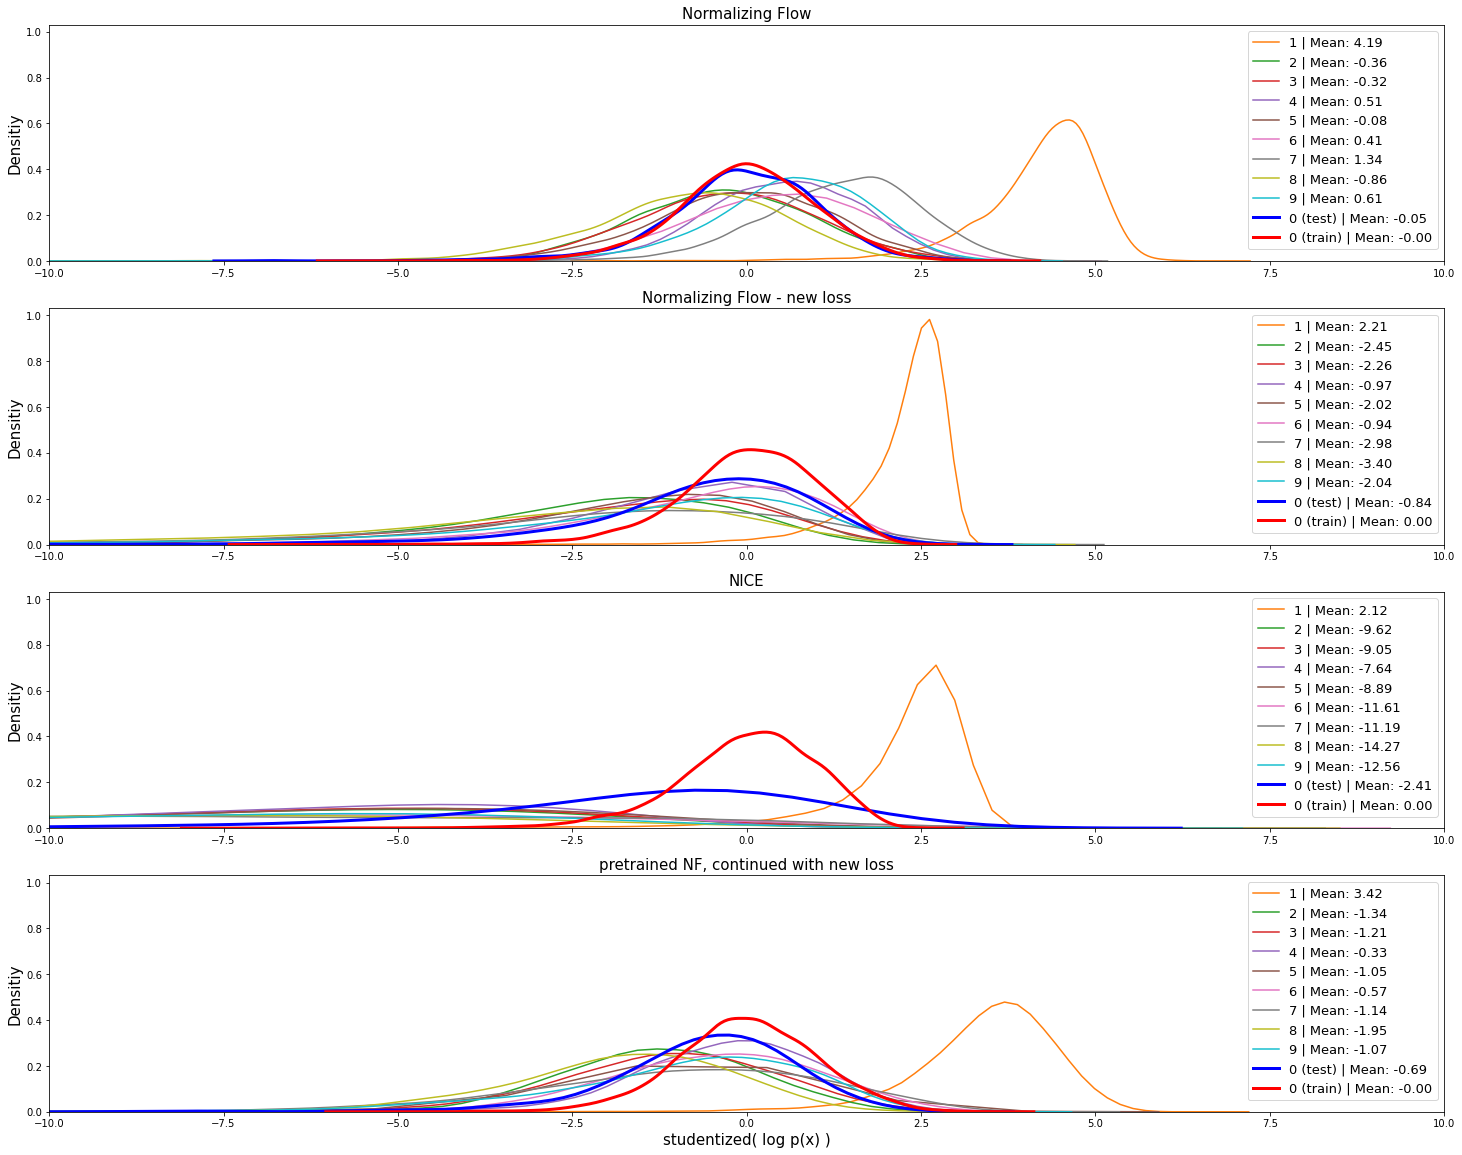

In [30]:
_=show_loss_histograms(all_models, score_idx=T_SCORE, lim_left=-10, lim_right=10)

In [7]:
interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, 1, 4, 6, 7, 9]
#interesting_classes = [MAIN_TEST_CLS, MAIN_TRAIN_CLS, 1,2,3,4,5,6,7,8,9]
all_models = filter_interesting_losses_and_equalize(all_models, interesting_classes, MAIN_TEST_CLS, ignore_classes=[MAIN_TRAIN_CLS])

In [8]:
improvements = dict()
for cls in all_models['nf']:
    improvements[cls] = np.zeros((len(all_models), len(all_models)))
improvements[AVERAGE_OUTLIERS] = np.zeros((len(all_models), len(all_models)))

# for all models with each other
for x, m1 in enumerate(all_models):
    for y, m2 in enumerate(all_models):
        # for all classes
        for cls in all_models[m1]:
            cls_data_1 = all_models[m1][cls][T_SCORE]
            cls_data_2 = all_models[m2][cls][T_SCORE]
            
            # we want to improve main class and make outliers worse    
            if cls == MAIN_TRAIN_CLS or cls == MAIN_TEST_CLS:
                score = np.maximum(cls_data_1, cls_data_2).mean()
            else:
                score = np.minimum(cls_data_1, cls_data_2).mean()
            #print(score)
            improvements[cls][y,x] = score

outlier_cls_count = 0
for cls in improvements:
    if cls != MAIN_TRAIN_CLS and cls != MAIN_TEST_CLS:
        improvements[AVERAGE_OUTLIERS] += improvements[cls]
        outlier_cls_count += 1
improvements[AVERAGE_OUTLIERS] /= outlier_cls_count

Title is the class


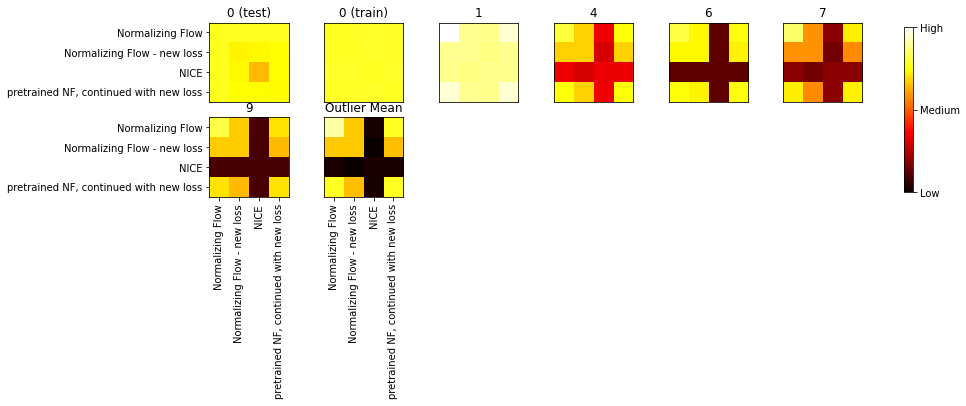

In [9]:
cols = 6
rows = int(np.ceil(len(improvements) / cols))
fig, axis = plt.subplots(rows, cols, figsize=(15, rows*1.6))
axs = axis.flatten()

# finds the minimum and maximum
vmin = 100
vmax = -1000
for i, cls in enumerate(improvements):
    vmin = min(vmin, improvements[cls].min())
    vmax = max(vmax, improvements[cls].max())
    
# plots the matrizes
for i, cls in enumerate(improvements):
    im = axs[i].matshow(improvements[cls], vmin=vmin, vmax=vmax, cmap='hot')
    # hot, copper, gist_heat
    #print(cls)
    #print(improvements[cls])
    
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_title(class_to_name(cls))

tick_names = [model_short_to_name(name) for name in all_models]
# sets the models names
for i in range(axis.shape[0]):
    axis[i, 0].set_yticks(np.arange(len(all_models)))
    axis[i, 0].set_yticklabels(tick_names)
for i in range(axis.shape[1]):
    ax = axis[axis.shape[0]-1, i]
    ax.set_xticks(np.arange(len(all_models)))
    ax.set_xticklabels(tick_names)
    ax.xaxis.set_ticks_position('bottom')
    
    plt.setp(ax.get_xticklabels(), rotation=90)
    
# remove unused subplots
for i in range(len(improvements), len(axs)):
    plt.delaxes(axs[i])

axs = axs[:len(improvements)]

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.95)
cbar.set_ticks([vmin, np.mean([vmin, vmax]), vmax])
cbar.set_ticklabels(['Low', 'Medium', 'High'])
print('Title is the class')

$\newcommand{\Dt}{D_0^t}$
$\newcommand{\Ce}{\mathfrak{C}}$

Definition of outlier score:<br>
Let 
Let $\Ce$ be the set of samples from outliers and $\Dt$ be the training set.<br>
$\Ce := \{D_c | c \neq 0\}$

For a given model $f$ that returns the log likelihood in bits per dim (i.e. $f(x) = \frac{p_X(x)}{\log(2) \cdot \dim(x)}$) <br>
$f'$ is the studentized version of $f$:<br>
$f'(x) = \frac{f(x) - \text{mean}(f)}{\text{var}(f)}$<br>
Mean and variance are calculated over $\Dt$.<br>
We refer to the score of $f'$ as t-score.<br><br>

$q_i$ is the $i$th quantile of the inliers:<br>
$q_i := \text{sort}(f'(D_0^t))[i \cdot |\Dt|]$<br>
That is, we apply $f'$ to all element in $\Dt$, sort these score and use that t-score such that $(1-i) \cdot 100$ percent of all samples in $\Dt$ obtain a higher t-score than $q_i$.<br><br>

Than we define the expert score $\Psi$:<br>
$\Phi_i(f) := \frac{1}{|\Ce|} \sum_{C \in \Ce} \left( \frac{1}{|C|} \sum_{c \in C} \mathbb{1}_{\{f'(c) > q_i\}} \right)$<br>
$\Psi_i(f) := \Phi_i(f) / $ mean how many inliers got categorised wrongly.
Which is: the average amount of samples of outliers averaged over all outlier classes, that obtain a higher t-score than $q_i$.<br>
We will use $\Psi_{0.01}$

In [10]:

def combine_models_to_expert(used_model):
    
    expert_model = dict()
    for cls in all_models['nf']:
        latent_info = dict()#[None] * (T_SCORE+1)
        latent_info[IMG_IDX] = all_models['nf'][cls][IMG_IDX]
        # there is no known likelihoood
        latent_info[LLN_IDX] = np.zeros_like(all_models['nf'][cls][LLN_IDX]) - 100

        score = None
        # in this loop we create the histogram for a potential best expert gate
        for model in used_model:
            #### besser zusammenfassen
            #print(model, cls)
            #print(all_models[model][cls].keys())
            score_of_current_model = all_models[model][cls][T_SCORE]
            # no initial score to compare with was set
            # thus we just take the values of the first model
            if score is None:
                score = score_of_current_model
            else:
                if cls == MAIN_TRAIN_CLS or cls == MAIN_TEST_CLS:
                    score = np.maximum(score, score_of_current_model)
                else:
                    score = np.minimum(score, score_of_current_model)

        latent_info[T_SCORE] = score
        expert_model[cls] = latent_info
        
    return expert_model
    
def compute_quantile_of_main_cls(expert, q=0.01):
    main_cls_scores = expert[MAIN_TRAIN_CLS][T_SCORE]
    sorted_main_cls_scores = np.sort(main_cls_scores)
    q = sorted_main_cls_scores[round(q * len(sorted_main_cls_scores))]
    return q

def psi_score(expert, q):
    """expert: given expoert
    q: actual quantile (location of that quantile)"""
    
    psi_per_class = []
    main_cls_test_score = None
    for cls in expert:
        if cls == MAIN_TRAIN_CLS:
            continue
        scores = expert[cls][T_SCORE]
        if cls == MAIN_TEST_CLS:
            main_cls_test_score = (scores > q).mean()
        else:
            psi_per_class.append((scores > q).mean())
            
    # compute true positive rate | sensitivity
    #return main_cls_test_score / (main_cls_test_score + np.mean(psi_per_class))
    # likelihood ratio for positive results
    TPR = main_cls_test_score
    FNR = 1 - TPR
    FPR = np.mean(psi_per_class)
    TNR = 1 - FPR
    
    return TPR + TNR - 1, (TPR, TNR)

    #return ((1-FP)
    #return main_cls_test_score / np.mean(psi_per_class)

def avg_precision(expert, dummy=None):
    true_class = []
    all_scores = []
    
    for cls in expert:
        if cls == MAIN_TRAIN_CLS:
            continue
            
        scores = expert[cls][T_SCORE]
        all_scores.append(-scores)
        if cls == MAIN_TEST_CLS or cls == MAIN_TRAIN_CLS:
            true_class.append(np.zeros_like(scores))
        else:
            true_class.append(np.ones_like(scores))
    
    all_scores = np.concatenate(all_scores)
    true_class = np.concatenate(true_class)
    
    ap = average_precision_score(true_class, all_scores)
    auroc = roc_auc_score(true_class, all_scores)
    return ap, auroc

#avg_precision(combine_models_to_expert(all_models.keys()))
#expert_model = theoretically_best_expert_with(all_models.keys())
#q = compute_quantile_of_main_cls(expert_model, q=0.01)

In [11]:
#all_experts = create_theoretical_experts(all_models, combine_models_to_expert, compute_quantile_of_main_cls, psi_score)
all_experts = create_theoretical_experts(all_models, combine_models_to_expert, compute_quantile_of_main_cls, avg_precision)
expert_scores=remove_experts_without_effect(all_experts, round_digits=2)

In [17]:
print(all_models['nf'].keys())
for model, score in expert_scores:
    if len(model) == 1:
        #print(f'{model_short_to_name(model[0])}:\t i:{score[0]:.3f}   TPR: {score[1][0]:.3f} TNR: {score[1][1]:.3f}')
        print(f'{model_short_to_name(model[0])}:\t AP:{score[0]:.3f} AUROC: {score[1]:.3f}')

dict_keys([0, 5000, 1, 4, 6, 7, 9])
NICE:	 AP:0.745 AUROC: 0.706
Normalizing Flow - new loss:	 AP:0.533 AUROC: 0.463
pretrained NF, continued with new loss:	 AP:0.486 AUROC: 0.400
Normalizing Flow:	 AP:0.366 AUROC: 0.242


In [25]:

ood = np.copy(all_models['nf'][7][T_SCORE])
np.sort(ood)
z = np.copy(all_models['nf'][MAIN_TRAIN_CLS][T_SCORE])
np.sort(z)

indices = np.searchsorted(z, ood)
indices

array([3330, 5923, 3172, 5923, 3172, 5865, 5923, 5923,  241, 5923, 3172,
       5880,  925, 5923, 5923, 3330, 4625, 5923, 3172, 5880, 5889, 5923,
       5923, 4437, 5923, 3246, 5923, 3330, 5923, 5923, 4434, 5923, 3172,
       5880,    0, 3172, 5923, 5923, 3246, 1652, 4134, 5923, 5923, 5923,
       3246, 5923, 3172, 5880, 2934, 1440, 3605, 5923, 5923, 4434, 3674,
       1899, 5923, 5923, 5923, 5923, 5923, 4434, 3674, 5923, 3246, 5923,
       3330, 5923, 5923,    0, 5923, 5923, 4434, 5923, 5923, 4434, 5898,
       5923, 5923,  241, 5923, 3246, 5923, 5923, 5923, 5923, 5923, 4434,
       5898, 5923, 5923, 5923, 5923, 5923, 4434, 5923, 5923, 3172, 5880,
       1009, 5463, 5866, 5684, 5508, 5466, 5866, 3681, 5357, 5191, 4981,
       5865, 5923, 5923, 5923, 3172,    9, 1528, 2642, 5782, 3547, 5923,
       5923, 5923,  241, 5370,  506, 5752, 5923, 3330, 5923, 5923, 4434,
       3605, 5923,  241, 5890, 3636, 5923, 3172, 5923, 5923, 5923, 5923,
       5923, 5923, 5923, 5923, 5923, 5923, 5923, 44

In [13]:
expert_scores

[(('nf', 'nf_new_loss', 'NICE', 'continued_new_loss'),
  (0.8817504415021715, 0.7955966264056644)),
 (('nf_new_loss', 'NICE', 'continued_new_loss'),
  (0.864328839392888, 0.7783850478967097)),
 (('nf_new_loss', 'NICE'), (0.8448157291509806, 0.7652634319033738)),
 (('NICE',), (0.7447738625337081, 0.7060297792586421)),
 (('nf', 'nf_new_loss', 'continued_new_loss'),
  (0.6720812452345301, 0.5689379425239484)),
 (('nf', 'nf_new_loss'), (0.654534818938306, 0.5526520199916701)),
 (('nf_new_loss', 'continued_new_loss'),
  (0.6016367502903106, 0.5048157017909205)),
 (('nf', 'continued_new_loss'), (0.588612930581726, 0.4883610995418576)),
 (('nf_new_loss',), (0.533096396990403, 0.4628821324448147)),
 (('continued_new_loss',), (0.48573215754427823, 0.3996865889212828)),
 (('nf',), (0.3658268653477821, 0.2423880674718867))]

In [14]:
#print(psi_score(expert_model, q))
all_models_and_expert = dict(all_models)
all_models_and_expert[expert_scores[0][0]] = combine_models_to_expert(expert_scores[0][0])

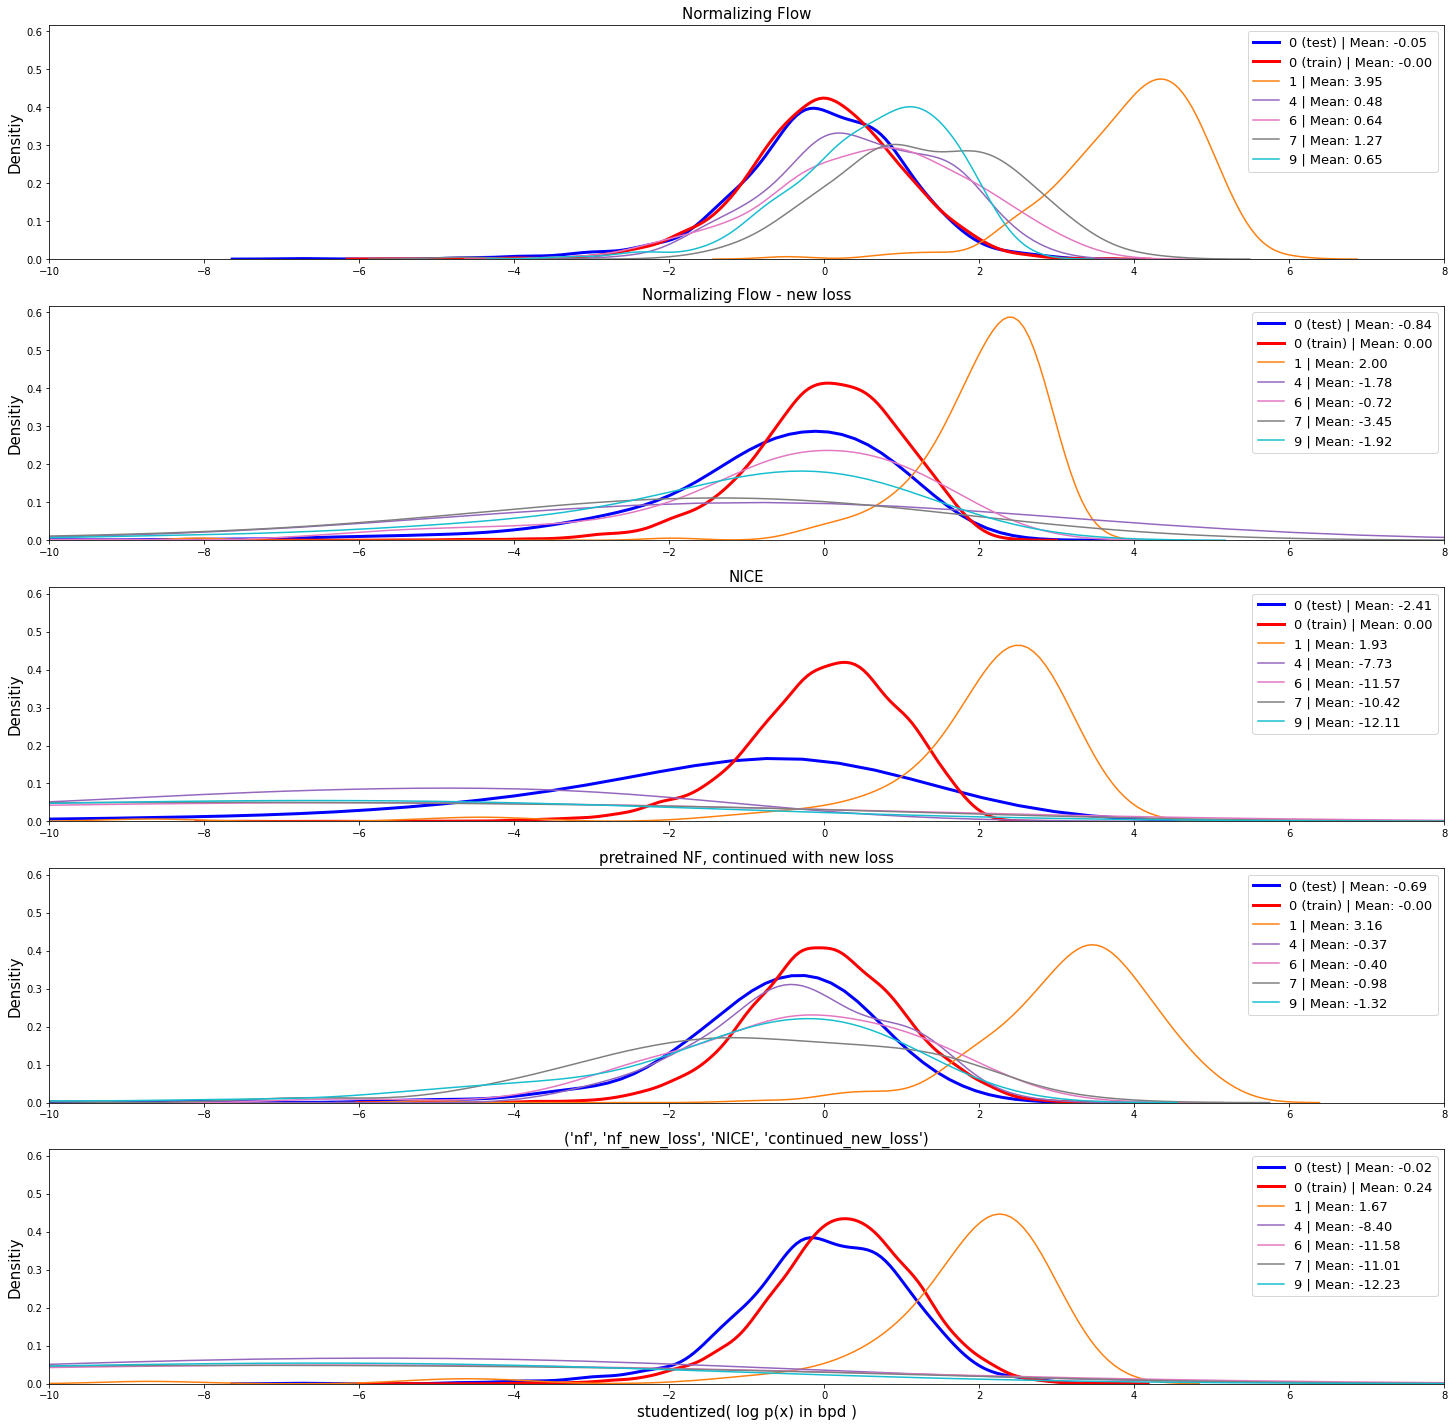

In [15]:
_=show_loss_histograms(all_models_and_expert, score_idx=T_SCORE, lim_left=-10,lim_right=8)